In [2]:
import pandas as  pd
import matplotlib.pyplot as plt
df=pd.read_csv("../data/cleaned_sales_data.csv")


In [3]:
df['estimated_revenue'] = df['discounted_price'] * df['rating_count']

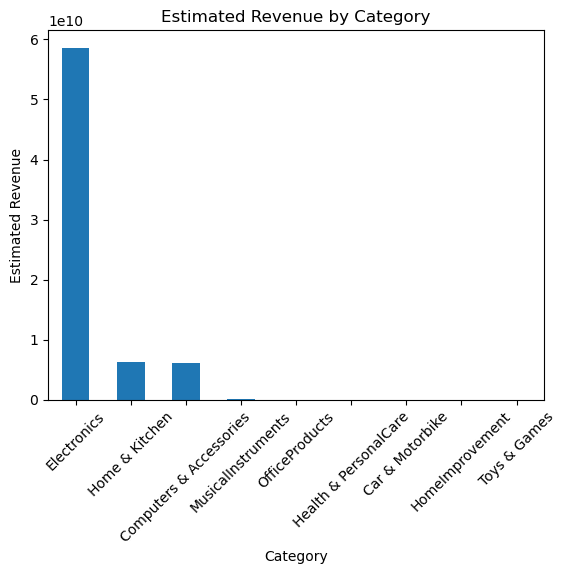

In [4]:
#revenue by category
category_revenue = df.groupby('main_category')['estimated_revenue'].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar')

plt.title("Estimated Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight
Electronics generates the highest estimated revenue among all categories.  
This shows that electronics products are the main revenue drivers for the business.

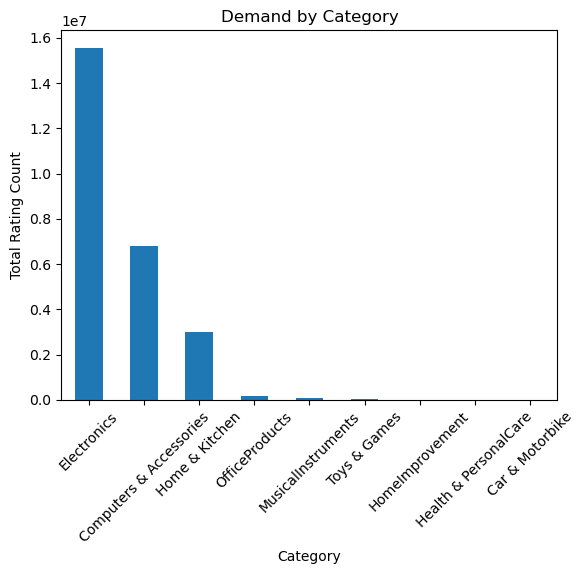

In [5]:
#demand by category
category_demand = df.groupby('main_category')['rating_count'].sum().sort_values(ascending=False)

category_demand.plot(kind='bar')

plt.title("Demand by Category")
plt.xlabel("Category")
plt.ylabel("Total Rating Count")
plt.xticks(rotation=45)
plt.show()

### Insight
Electronics also has the highest demand based on rating count.  
This confirms that it is both the most popular and the most important category for sales.

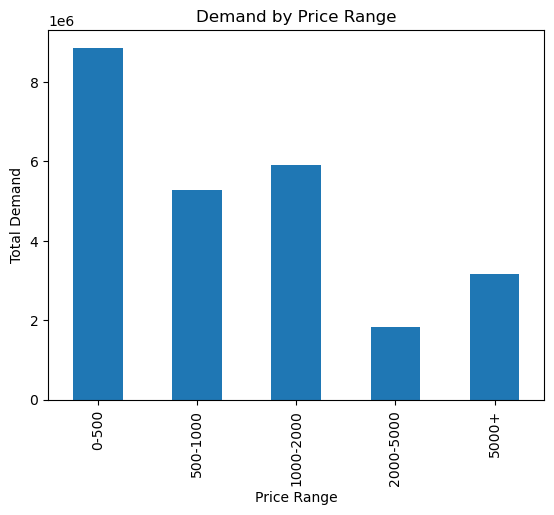

In [6]:
#demand by price range
bins = [0, 500, 1000, 2000, 5000, 20000]
labels = ['0-500', '500-1000', '1000-2000', '2000-5000', '5000+']

df['price_range'] = pd.cut(df['discounted_price'], bins=bins, labels=labels)

price_demand = df.groupby('price_range', observed=True)['rating_count'].sum()

price_demand.plot(kind='bar')

plt.title("Demand by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Total Demand")
plt.show()

### Insight
Demand is highest in the 0–500 price range, followed by mid-range products.  
This indicates that customers strongly prefer affordable products.

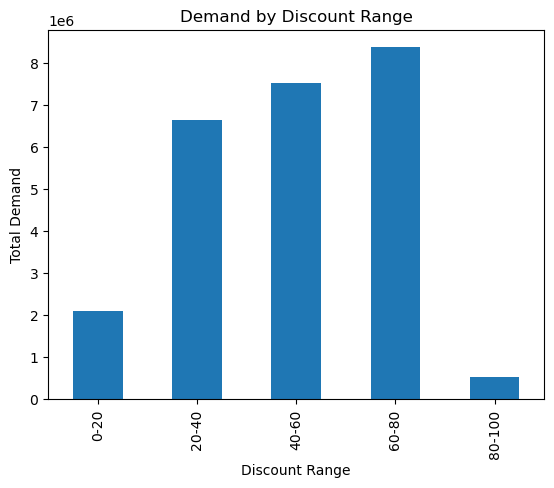

In [8]:
#demand by discount range
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']

df['discount_range'] = pd.cut(df['discount_percentage'], bins=bins, labels=labels)

discount_demand = df.groupby('discount_range', observed=True)['rating_count'].sum()

discount_demand.plot(kind='bar')

plt.title("Demand by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Total Demand")
plt.show()

### Insight
Products with discounts between 60% and 80% show the highest demand.  
This suggests that moderate to high discounts are most effective in attracting customers.

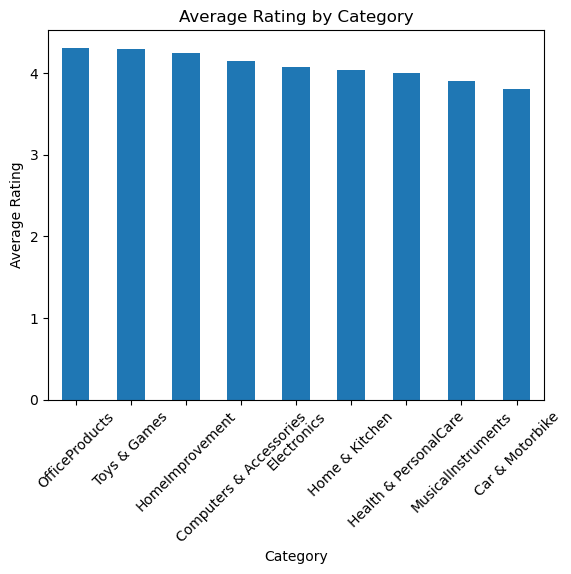

In [9]:
#avg rating by category
category_rating = df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

category_rating.plot(kind='bar')

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

### Insight
Some smaller categories such as Office Products and Toys & Games have higher average ratings than Electronics.  
This shows that the highest revenue category is not necessarily the most satisfying for customers.

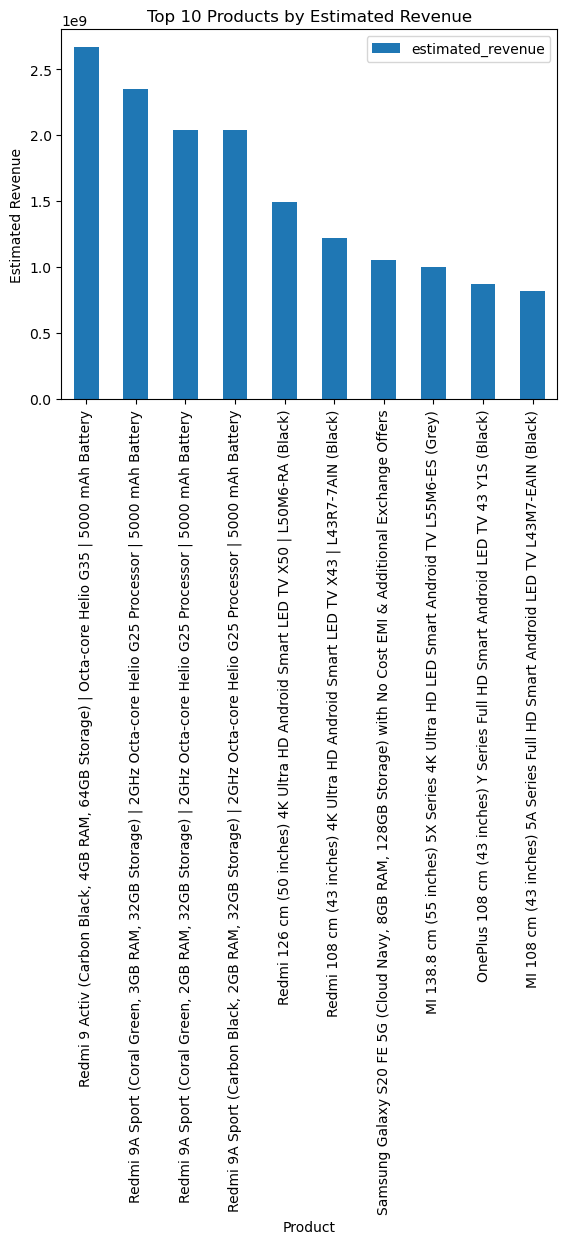

In [10]:
#top 10 products
top_revenue_products = df[['product_name', 'estimated_revenue']].sort_values(by='estimated_revenue', ascending=False).head(10)

top_revenue_products.plot(kind='bar', x='product_name', y='estimated_revenue')

plt.title("Top 10 Products by Estimated Revenue")
plt.xlabel("Product")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=90)
plt.show()

### Insight
A small number of products contribute a very large share of total revenue.  
This indicates that a few star products play a major role in overall business performance.

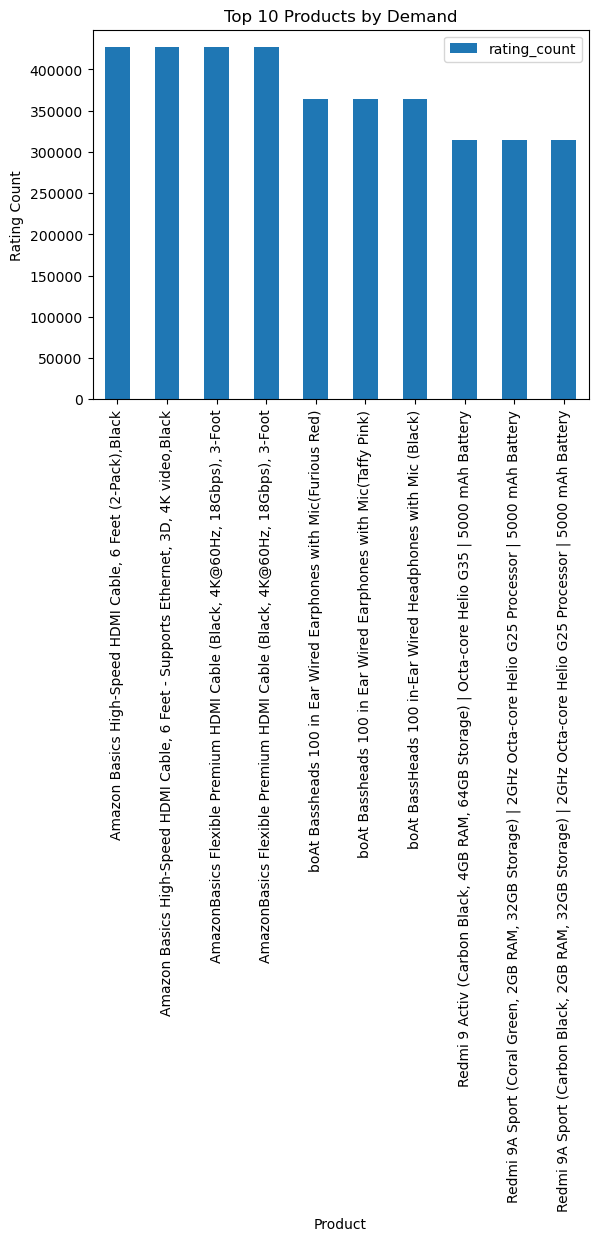

In [11]:
#top 10 demand products
top_demand_products = df[['product_name', 'rating_count']].sort_values(by='rating_count', ascending=False).head(10)

top_demand_products.plot(kind='bar', x='product_name', y='rating_count')

plt.title("Top 10 Products by Demand")
plt.xlabel("Product")
plt.ylabel("Rating Count")
plt.xticks(rotation=90)
plt.show()

### Insight
The most demanded products are mostly affordable accessories and electronics.  
This reinforces the pattern that lower-priced, frequently purchased items drive customer activity.

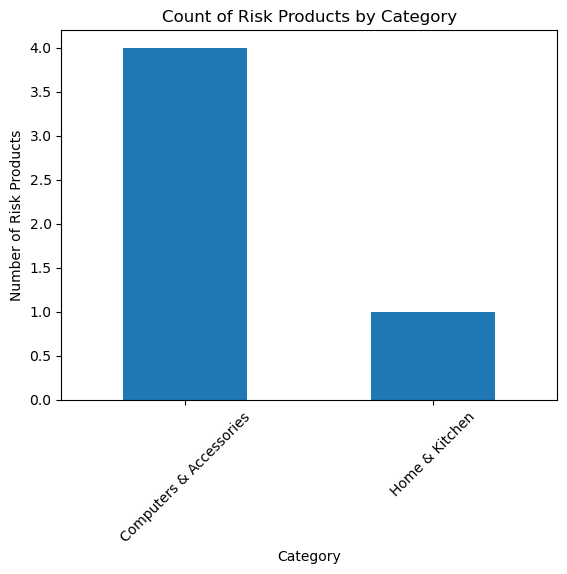

In [12]:
#risk products which has low rating but high demand
risk_products = df[(df['rating'] < 3.5) & (df['rating_count'] > df['rating_count'].median())]

risk_summary = risk_products.groupby('main_category')['rating_count'].count().sort_values(ascending=False)

risk_summary.plot(kind='bar')

plt.title("Count of Risk Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Risk Products")
plt.xticks(rotation=45)
plt.show()

### Insight
Some categories contain products with high demand but low ratings, especially in Computers & Accessories.  
These products may create customer dissatisfaction despite generating sales.